In [ ]:
# Import libary yang dibutuhkan
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
%matplotlib inline

In [ ]:
df = pd.read_csv("bank.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [36]:
df['y'].unique()

array(['no', 'yes'], dtype=object)

In [37]:
df.shape

(4521, 17)

In [38]:
d = df.describe()
d

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


/tmp/ipykernel_8613/1690163383.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='RdBu_r')


<Axes: xlabel='y', ylabel='count'>

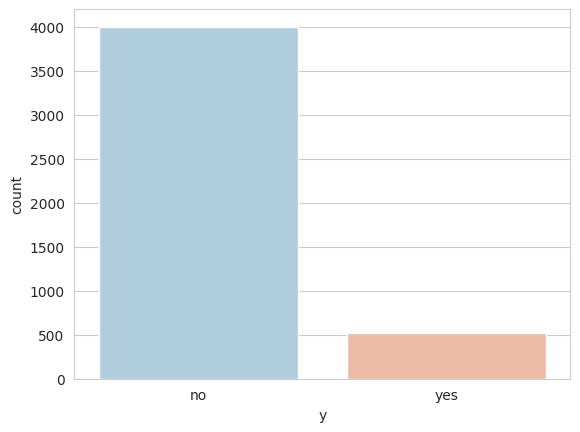

In [39]:
sns.set_style('whitegrid')
sns.countplot(x='y', data=df, palette='RdBu_r')

<Axes: xlabel='y', ylabel='count'>

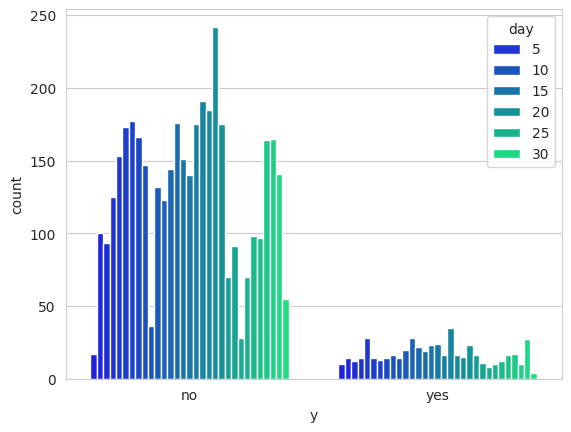

In [40]:
sns.set_style('whitegrid')
sns.countplot(x='y', hue='day', data=df, palette='winter')

/tmp/ipykernel_8613/933486587.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y',y='age',data=df,palette='winter')


<Axes: xlabel='Menerima dan Menolak', ylabel='Age'>

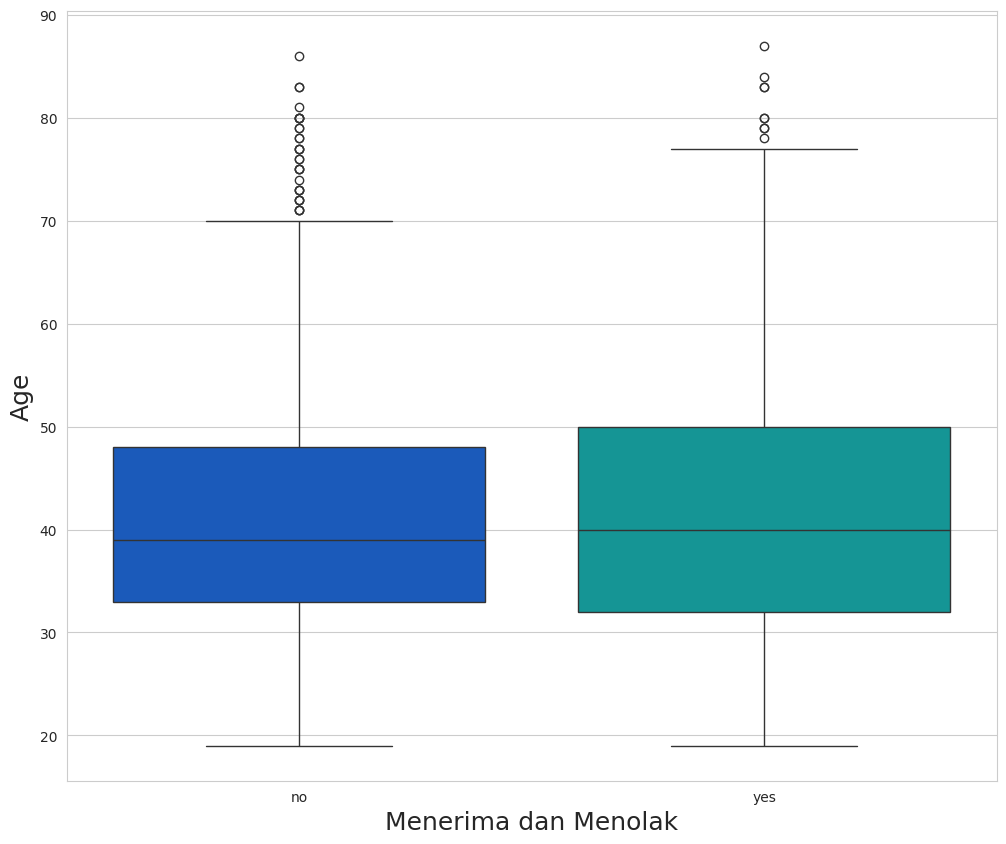

In [41]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Menerima dan Menolak",fontsize=18)
plt.ylabel("Age",fontsize=18)
sns.boxplot(x='y',y='age',data=df,palette='winter')

/home/sevti/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


<function matplotlib.pyplot.show(close=None, block=None)>

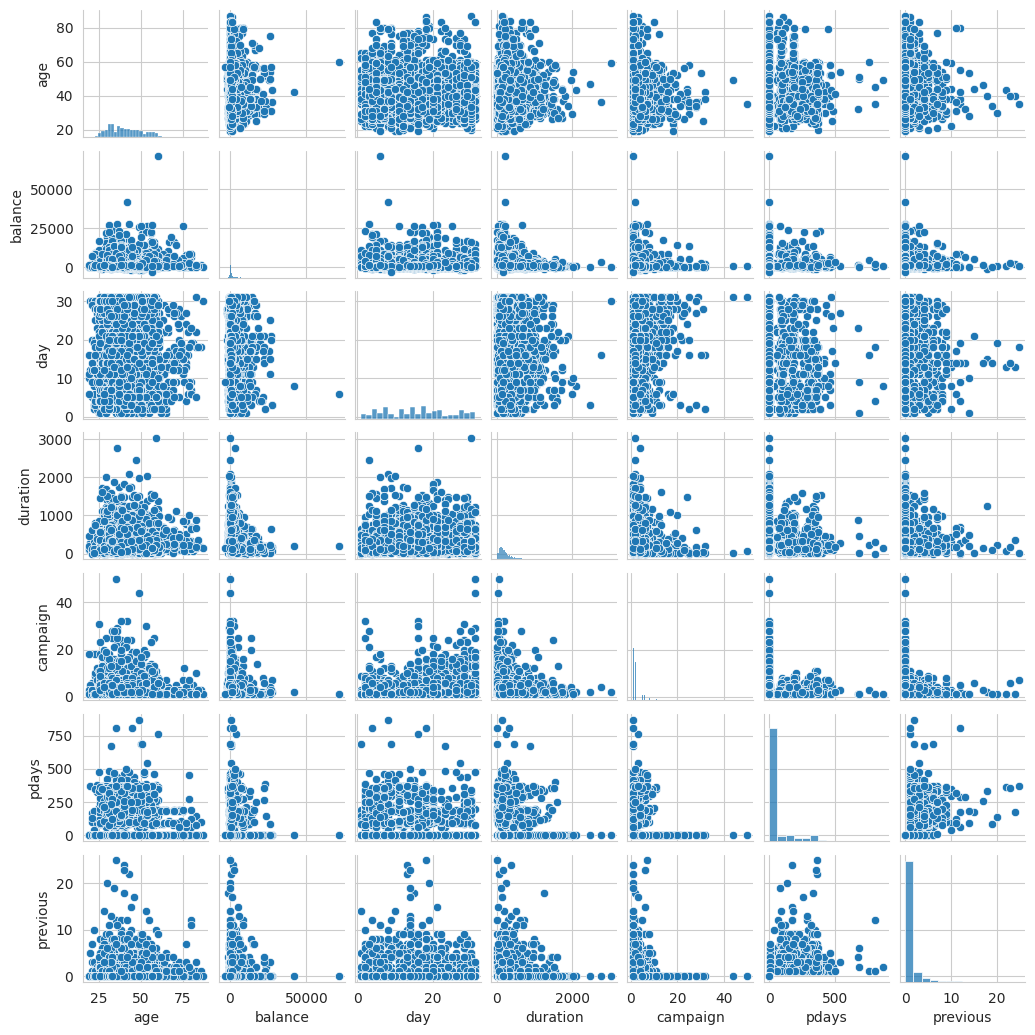

In [42]:
sns.pairplot(df,size=1.5)
plt.show

<Axes: >

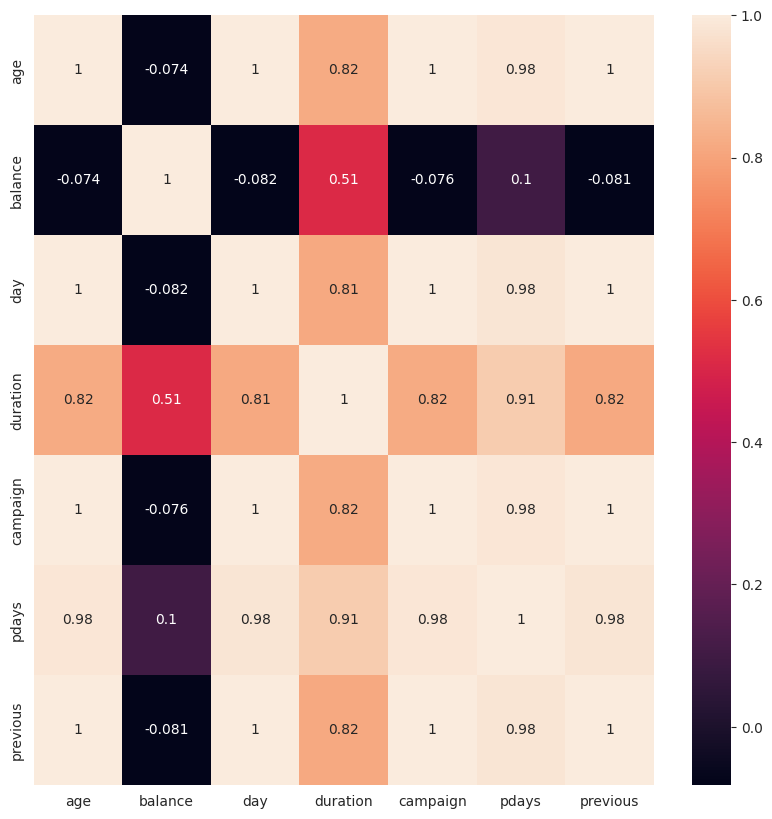

In [43]:
plt.figure(figsize=(10, 10))
sns.heatmap(d.corr(),annot=True)

<Axes: title={'center': 'Histogram Duration'}, xlabel='Duration', ylabel='Count'>

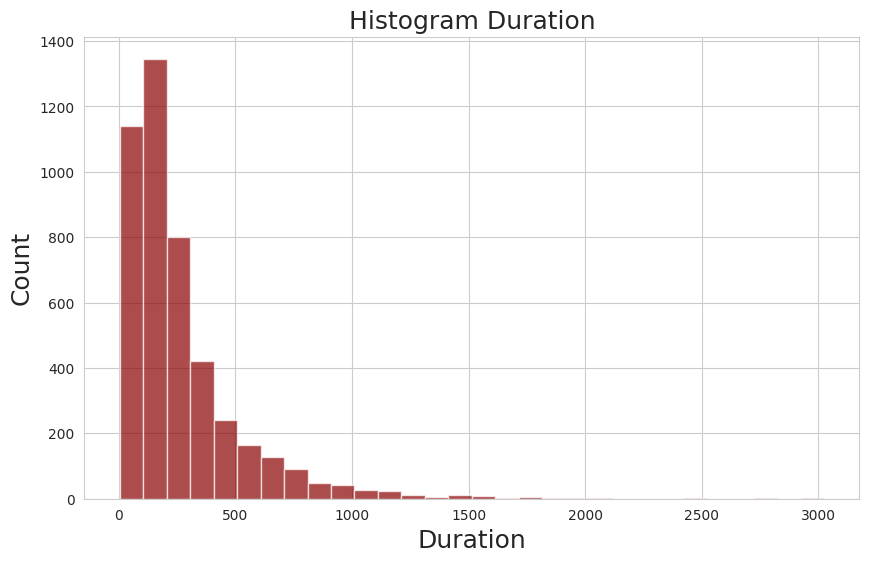

In [44]:
# Cek Distribusi dari duration
plt.xlabel("Duration", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Duration", fontsize=18)
df['duration'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10, 6))

         balance
y               
no   1403.211750
yes  1571.955854


(array([0, 1]), [Text(0, 0, 'no'), Text(1, 0, 'yes')])

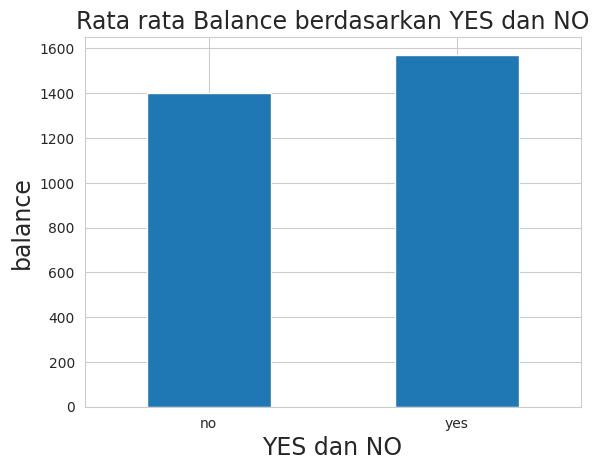

In [45]:
f_class_balance = df.groupby('y')['balance'].mean()
f_class_balance = pd.DataFrame(f_class_balance)
print(f_class_balance)

f_class_balance.plot.bar(y='balance', legend=False)
plt.title("Rata rata Balance berdasarkan YES dan NO", fontsize=17)
plt.xlabel("YES dan NO", fontsize=17)
plt.ylabel("balance", fontsize=17)
plt.xticks(rotation=0)


### Fitur Engineering

In [46]:
a = list(f_class_balance['balance'])

def impute_balance(cols):
    Balance = cols['balance']
    y = cols['y']
    
    if pd.isnull(Balance):
        if y == 'no':
            return a[0]
        elif y == 'yes':
            return a[1]
        else:
            return a[2]
    
    else:
        return Balance

In [47]:
df['balance'] = df[['balance', 'y']].apply(impute_balance, axis=1)

Text(0.5, 1.0, 'Bar Plot Jumlah Fitur Numerik Dataset Bank')

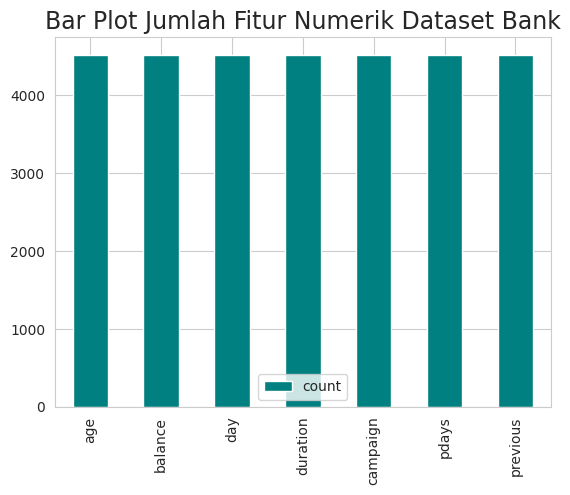

In [48]:
d = df.describe()
dT = d.T
dT.plot.bar(y='count', color='teal')
plt.title("Bar Plot Jumlah Fitur Numerik Dataset Bank", fontsize=17)

In [49]:
df.drop('poutcome', axis=1, inplace=True)
df.dropna(inplace=True)
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,no


In [50]:
df.drop(['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'contact'], axis=1, inplace=True)
df.dropna(inplace=True)
df.head()

,age,balance,day,duration,campaign,pdays,previous,y
0,30,1787,19,79,1,-1,0,no
1,33,4789,11,220,1,339,4,no
2,35,1350,16,185,1,330,1,no
3,30,1476,3,199,4,-1,0,no
4,59,0,5,226,1,-1,0,no


In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])
df.head()

,age,balance,day,duration,campaign,pdays,previous,y
0,30,1787,19,79,1,-1,0,0
1,33,4789,11,220,1,339,4,0
2,35,1350,16,185,1,330,1,0
3,30,1476,3,199,4,-1,0,0
4,59,0,5,226,1,-1,0,0


## Training

In [52]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('y', axis=1),
                                                    df['y'], test_size=0.30,
                                                    random_state=42)

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [54]:
print(f"Train Shape : {X_train.shape}")
print(f"Test Shape : {X_test.shape}")

Train Shape : (3164, 7)
Test Shape : (1357, 7)


## **KNN**

In [55]:
from sklearn.neighbors import KNeighborsClassifier

class1 = KNeighborsClassifier()
class1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [56]:
y_pred = class1.predict(X_test)

### Evaluation

In [57]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN : {accuracy:.2f}")

print("Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred))

print("Classification_report : ")
print(classification_report(y_test, y_pred))

Akurasi Model KNN : 0.88
Confusion Matrix : 
[[1155   50]
 [ 114   38]]
Classification_report : 
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1205
           1       0.43      0.25      0.32       152

    accuracy                           0.88      1357
   macro avg       0.67      0.60      0.63      1357
weighted avg       0.86      0.88      0.86      1357



In [58]:
class1 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
class1.fit(X_train, y_train)

y_pred1 = class1.predict(X_test)

In [59]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 0.88
Confusion Matrix:
[[1153   52]
 [ 114   38]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1205
           1       0.42      0.25      0.31       152

    accuracy                           0.88      1357
   macro avg       0.67      0.60      0.62      1357
weighted avg       0.86      0.88      0.86      1357



In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.876106   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.873896   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.880215   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.869156   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.870103   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.879268   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.882428   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.881480   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.878950   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.877371   
10  {'metric': 'manhattan', 'n_neighbors

In [61]:
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_model_KNN(bank).xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_model_KNN(bank).xlsx'")

Hasil telah disimpan ke 'hasil_model_KNN(bank).xlsx'


In [62]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [63]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi : {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi : {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall : {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score {f1_score(y_test, y_pred, average='micro'):.2f}")
print("\nClassification Report : ")
print(classification_report(y_test, y_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi : 0.88
Presisi : 0.67
Recall : 0.61
F1-Score 0.88

Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1205
           1       0.44      0.26      0.32       152

    accuracy                           0.88      1357
   macro avg       0.67      0.61      0.63      1357
weighted avg       0.86      0.88      0.87      1357

Confusion Matrix : 
[[1155   50]
 [ 113   39]]


In [64]:
new_data = np.array([[25, 1440, 19, 300, 1, 330, 0]])

prediction = best_model.predict(new_data)

prediction_label = le.inverse_transform(prediction)

print("Menerima Membuka bank YES atau NO : ", prediction_label[0])

Menerima Membuka bank YES atau NO :  no
